In [1]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_French-GSD"

treebank_path = "/Users/madalina/Downloads/bUD_English-GUM"
# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Wolof-WTB"
treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Chinese-GSD"
# treebank_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/input/Universal_Dependencies/ud-treebanks-v2.15/UD_Japanese-GSD"
grew_pattern = "pattern{X[upos<>PUNCT]}"
patterns_text_file = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"
analysed_category = "all_nodes"

corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=grew_pattern,
    patterns_text_file=patterns_text_file,
    use_sud=False,
    matrix_type="coverage",
    # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"own", r"Gender"] # for french
        # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"XML=", r"PDTB=", r"SplitAnte=", r"MSeg=", r"Entity=", r"Discourse=", r"Bridge=", r"own", r"Degree=Pos"] # for english
    excluded_feature_patterns = [r"own", r"Translit"] #for chinese
    # excluded_feature_patterns=[r"UnidicInfo=", r"LUWPOS=", r"PrevUDLemma", r"own"] # for japanese
)

connected to port: 53619


In [ ]:
corpus._feature2idx

In [2]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(corpus.feature_matrix)

In [3]:
import numpy as np
results = []
lex_units_with_different_neighbours = set()
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        if neighbour_category != current_category and similarity_matrix[idx][neighbour_idx] > 0.5:
            diff = np.abs(corpus.feature_matrix[idx] - corpus.feature_matrix[neighbour_idx])
            closest_features_idx= np.argsort(diff)[:-6:-1]
            closest_features = [corpus._idx2feature[i] for i in closest_features_idx]
                
            results.append({
                "lex_unit": lex_unit,
                "neighbour_lex_unit": corpus._idx2lexunit[neighbour_idx],
                "distance": similarity_matrix[idx][neighbour_idx],
                "closest_features": closest_features,
                
            })
            lex_units_with_different_neighbours.add(lex_unit)
    

for r in results:
    print(r)   

{'lex_unit': ('/', 'SYM'), 'neighbour_lex_unit': ('的', 'PART'), 'distance': 0.8816753889255792, 'closest_features': ['node:X:parent:position=after', 'node:X:parent:position=before', 'node:X:parent:upos=X', 'node:X:prev:upos=X', 'node:X:parent:upos=PART']}
{'lex_unit': ('/', 'SYM'), 'neighbour_lex_unit': ('復興', 'NOUN'), 'distance': 0.8615591378856822, 'closest_features': ['node:X:parent:position=before', 'node:X:prev:upos=NOUN', 'node:X:parent:position=after', 'node:X:next:upos=NOUN', 'node:X:parent:upos=X']}
{'lex_unit': ('/', 'SYM'), 'neighbour_lex_unit': ('保護', 'NOUN'), 'distance': 0.8615271557760302, 'closest_features': ['node:X:parent:position=before', 'node:X:parent:position=after', 'node:X:next:upos=NOUN', 'node:X:parent:upos=NOUN', 'node:X:prev:upos=NOUN']}
{'lex_unit': ('/', 'SYM'), 'neighbour_lex_unit': ('17', 'NUM'), 'distance': 0.8527699682128035, 'closest_features': ['node:X:parent:position=before', 'node:X:parent:position=after', 'node:X:next:upos=NOUN', 'node:X:parent:upo

In [ ]:
len(lex_units_with_different_neighbours)

In [4]:
category_counts = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    category = lex_unit[1]
    if category not in category_counts:
        category_counts[category] = {"total": 0, "with_different_neighbour": 0}
    category_counts[category]["total"] += 1
    if lex_unit in lex_units_with_different_neighbours:
        category_counts[category]["with_different_neighbour"] += 1

for category, counts in category_counts.items():
    total = counts["total"]
    with_diff = counts["with_different_neighbour"]
    percentage = (with_diff / total) * 100 if total > 0 else 0
    print(f"Category: {category}, Total: {total}, With Different Neighbour: {with_diff}, Percentage: {percentage:.2f}%")

Category: SYM, Total: 1, With Different Neighbour: 1, Percentage: 100.00%
Category: NUM, Total: 148, With Different Neighbour: 47, Percentage: 31.76%
Category: X, Total: 5, With Different Neighbour: 4, Percentage: 80.00%
Category: ADJ, Total: 105, With Different Neighbour: 77, Percentage: 73.33%
Category: DET, Total: 33, With Different Neighbour: 33, Percentage: 100.00%
Category: NOUN, Total: 1084, With Different Neighbour: 412, Percentage: 38.01%
Category: ADV, Total: 99, With Different Neighbour: 99, Percentage: 100.00%
Category: ADP, Total: 83, With Different Neighbour: 83, Percentage: 100.00%
Category: VERB, Total: 517, With Different Neighbour: 95, Percentage: 18.38%
Category: PROPN, Total: 227, With Different Neighbour: 167, Percentage: 73.57%
Category: SCONJ, Total: 38, With Different Neighbour: 38, Percentage: 100.00%
Category: CCONJ, Total: 16, With Different Neighbour: 16, Percentage: 100.00%
Category: PART, Total: 209, With Different Neighbour: 28, Percentage: 13.40%
Categor

In [5]:
from scipy.stats import entropy
scores = {}
for idx, lex_unit in corpus._idx2lexunit.items():
    current_category = lex_unit[1]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    purity_top, purity_bottom = 0, 0
    category_weights = {}
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour # the sum of all the inverse weights
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour

        if neighbour_category == current_category:
            purity_top += distance_to_neighbour

    purity_score = purity_top / purity_bottom

    probabilities = [v / purity_bottom for v in category_weights.values()]
    entropy_score = entropy(probabilities)
    
    scores[lex_unit] = {}
    scores[lex_unit]["purity"] = purity_score
    scores[lex_unit]["entropy"] = entropy_score

    rival_cat = None
    rival_weight = 0

    for cat, w in category_weights.items():
        if cat != current_category and w > rival_weight:
            rival_weight = w
            rival_cat = cat

    scores[lex_unit]["rival_category"] = rival_cat
    scores[lex_unit]["rival_weight_ratio"] = rival_weight / purity_bottom if purity_bottom > 0 else 0
    

In [ ]:
scores

In [6]:
import plotly.express as px
import pandas as pd

# Convert your 'scores' dictionary to a DataFrame
df = pd.DataFrame.from_dict(scores, orient='index')

# # Assuming lex_unit was a tuple (word, pos)
# df['word'] = df.index.apply(lambda x: x[0])
# df['category'] = df['index'].apply(lambda x: x[1])

# # Calculate medians for the dashed lines
med_p = df['purity'].median()
med_e = df['entropy'].median()

fig = px.scatter(
    df, x="purity", y="entropy",  
    hover_name=list(df.index),
    hover_data={
        "purity": True,
        "entropy": True,
        "rival_category": True,
        "rival_weight_ratio": True
    },
    title="Polycategoriality Analysis: Purity vs Entropy",
    labels={"purity": "Purity (Categorical Homogeneity)", "entropy": "Entropy (Categorical Competition)", "rival_category": "Other category around", "rival_weight_ratio": "Its weight"},
    # template="plotly_dark" # Or "plotly_white"
)

# Add the "Crosshair" at the medians

fig.add_vline(x=med_p, line_dash="dash", line_color="gray", opacity=0.5)
fig.add_hline(y=med_e, line_dash="dash", line_color="gray", opacity=0.5)

fig.show()

/opt/homebrew/lib/python3.11/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identify the 'Rival' for each unit
matrix_data = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    
    # We only care about units that have some level of 'pull' from others
    if stats['rival_category'] is not None:
        
       matrix_data.append(
           {
               "Original": current_cat,
               "Rival": stats['rival_category']
           }
       )
df_transitions = pd.DataFrame(matrix_data)
transition_matrix = pd.crosstab(
    df_transitions['Original'], 
    df_transitions['Rival'], 
    normalize='index'
)


In [8]:
all_overlaps = []

for lex_unit, stats in scores.items():
    current_cat = lex_unit[1]
    # Recalculate weights for THIS lex_unit
    idx = corpus._lexunit2idx[lex_unit]
    closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
    closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
    
    purity_bottom = 0
    category_weights = {}
    
    for neighbour_idx in closest_neighbours:
        neighbour_category = corpus._idx2lexunit[neighbour_idx][1]
        distance_to_neighbour = similarity_matrix[idx][neighbour_idx]
        purity_bottom += distance_to_neighbour
        
        if neighbour_category in category_weights:
            category_weights[neighbour_category] += distance_to_neighbour
        else:
            category_weights[neighbour_category] = distance_to_neighbour
    
    for rival_cat, weight in category_weights.items():
        if rival_cat != current_cat:
            all_overlaps.append({
                "Original": current_cat,
                "Rival": rival_cat,
                "Weight": weight / purity_bottom if purity_bottom > 0 else 0
            })

df_overlaps = pd.DataFrame(all_overlaps)
# Group by Original and Rival, then sum the weights and normalize
transition_matrix = df_overlaps.groupby(['Original', 'Rival'])['Weight'].sum().unstack(fill_value=0)
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

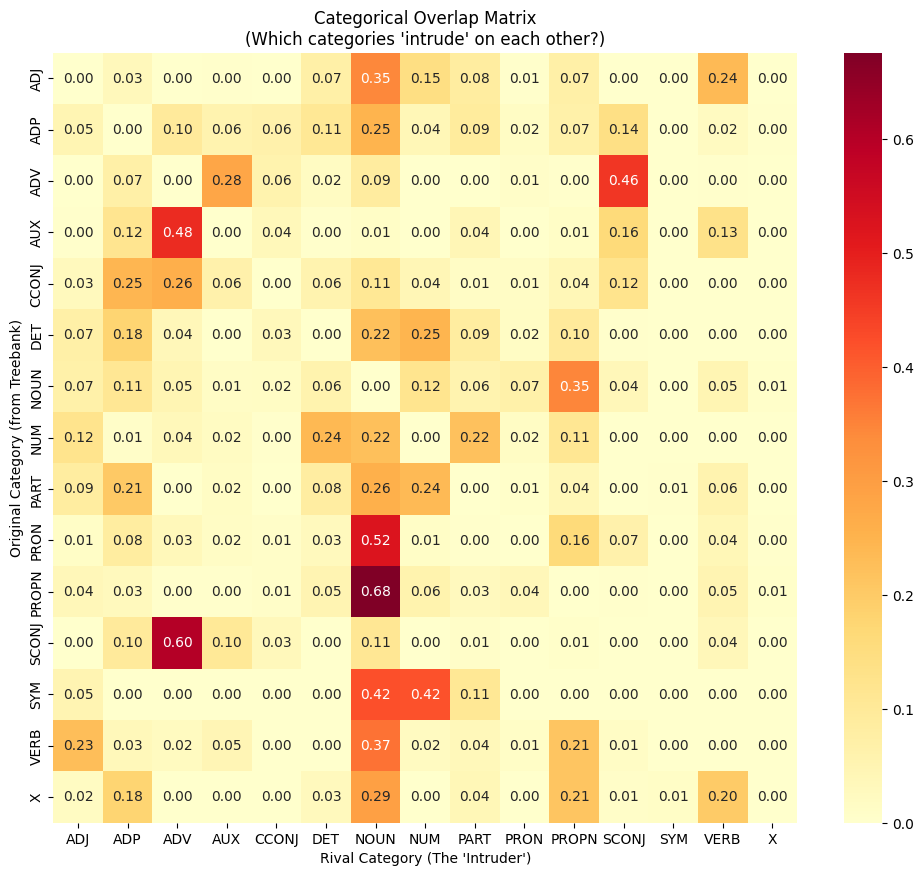

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    transition_matrix, 
    annot=True,      # Show the numbers in the cells
    cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
    fmt=".2f"        # Format to 2 decimal places
)

plt.title("Categorical Overlap Matrix\n(Which categories 'intrude' on each other?)")
plt.ylabel("Original Category (from Treebank)")
plt.xlabel("Rival Category (The 'Intruder')")
plt.show()

In [ ]:
def get_top_bridge_words(scores_dict, original_cat, rival_cat, top_n=100):
    """Finds the words from original_cat most pulled toward rival_cat."""
    matches = []
    
    for (word, o_cat), data in scores_dict.items():
        if o_cat == original_cat and data["rival_category"] == rival_cat:
            matches.append((word, data["purity"], data["entropy"]))
            
    # Sort by lowest purity (the ones most 'pulled' away)
    matches.sort(key=lambda x: x[1])
    
    return matches[:top_n]

# Example: Who are the Verbs that look like Adjectives?
category_to_compare_1 = "ADJ"
category_to_compare_2 = "VERB"
bridge_verbs = get_top_bridge_words(scores, category_to_compare_1, category_to_compare_2)
print(f"Top {category_to_compare_1} -> {category_to_compare_2} bridge words: ")
print(f"Word \t Purity \t Entropy")
for v in bridge_verbs:
    print(v)

In [ ]:
def get_pulling_features(lex_unit, rival_category, corpus, similarity_matrix, top_k_features=20):
    lex_unit_vector = corpus.feature_matrix[corpus._lexunit2idx[lex_unit]]
    closest_neighbours_indices = np.argsort(similarity_matrix[idx])[::-1]
    rival_cat_neighbours_idx = []
    for i in closest_neighbours_indices:
        if i != corpus._lexunit2idx[lex_unit] and corpus._idx2lexunit[i][1] == rival_category:
            rival_cat_neighbours_idx.append(i)
    
    rival_centroid = np.median(corpus.feature_matrix[rival_cat_neighbours_idx[:20]], axis=0)
    
    feat_idx_to_compare = []
    for feature_value_idx in range(len(rival_centroid)):
        if rival_centroid[feature_value_idx] > 0:
            feat_idx_to_compare.append(feature_value_idx)

    diffs = {}
    for f in feat_idx_to_compare:
        diff = abs(lex_unit_vector[f] - rival_centroid[f])
        diffs[f] = diff

    for f_idx, diff in diffs.items():
        print(corpus.idx2feature(idx), diff)
    # feature_differences = np.abs(lex_unit_vector - rival_centroid)
    
    # global_variance = np.var(corpus.feature_matrix, axis=0)

    # bridge_score = global_variance / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(bridge_score)[::-1][:top_k_features]

    # most_similar_features = {}
    # for i in range(len(feature_differences)):
    #     if feature_differences[i] > 0:
    #         most_similar_features[corpus._idx2feature[i]] = feature_differences[i]
    
    # sorted_most_similar_features = {k: v for k, v in sorted(most_similar_features.items(), key = lambda item: item[1])}
    # print(sorted_most_similar_features)
    # # We rank by (Value / (Difference + epsilon)) 
    # # This prioritizes high-frequency features that match the rival perfectly
    # relevance_score = lex_unit_vector / (feature_differences + 1e-6)
    # top_feature_indices = np.argsort(relevance_score)[::-1][:top_k_features]
    # results = []
    # for f_idx in top_feature_indices:
    #     print(corpus._idx2feature[f_idx])
    #     # results.append(
    #     #     {
    #     #     "feature": corpus._idx2feature[f_idx],
    #     #     "unit_value": lex_unit_vector[f_idx],
    #     #     "rival_avg": rival_centroid[f_idx],
    #     #     "diff": feature_differences[f_idx]
    #     #     }
    #     # )


In [ ]:
get_pulling_features(('willing', 'ADJ'), "VERB", corpus, similarity_matrix)

In [ ]:
result = get_pulling_features(('有名', 'ADJ'), "VERB", corpus, similarity_matrix)
print(result)

In [10]:
# The standard Universal Dependencies tags
UPOS_LIST = [
    'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'NOUN', 'NUM', 
    'PART', 'PRON', 'PROPN', 'SCONJ', 'SYM', 'VERB', 'INTJ', 'X'
]

# This creates column names like ADJ_to_VERB, ADJ_to_NOUN, etc.
column_names = [f"{src}_to_{tgt}" for src in UPOS_LIST for tgt in UPOS_LIST if src != tgt]

In [11]:
def process_treebank(path, language_name):

    # --- LOAD CORPUS (Your existing logic) ---
    corpus = tod.corpus.Corpus(
        treebank_path=path,
        grew_pattern=grew_pattern,
        patterns_text_file=patterns_text_file,
        use_sud=False,
        matrix_type="coverage",
        excluded_feature_patterns=[r"own"],
        included_feature_patterns=[r"upos=", 
                                    r"position=", 
                                    r"rel_shallow=",
                                    r"Abbr=", 
                                    r"Aspect=",  
                                    r"Animacy=",  
                                    r"Case=",  
                                    r"Clusivity=",  
                                    r"Definite=",  
                                    r"Deixis=", 
                                    r"DeixisRef",  
                                    r"Evident=",  
                                    r"Negation=",
                                    r"Number=",  
                                    r"Gender=",  
                                    r"Degree=",  
                                    r"ExtPos=", 
                                    r"Foreign=", 
                                    r"Mood",  
                                    r"NounClass=",  
                                    r"NumType=",  
                                    r"Person=",  
                                    r"Polarity=", 
                                    r"Polite=",  
                                    r"Poss=",  
                                    r"PronType=",  
                                    r"Reflex=",  
                                    r"Tense=",  
                                    r"Typo=",     
                                    r"VerbForm=",  
                                    r"Voice=",   ])
    
    similarity_matrix = cosine_similarity(corpus.feature_matrix)
    
    # --- CALCULATE AGGREGATE OVERLAPS ---
    # We want: Sum of weights for Source_Cat -> Target_Cat
    # Initialize a container for this language
    # Rows = Original, Cols = Rival
    lang_stats = pd.DataFrame(0.0, index=UPOS_LIST, columns=UPOS_LIST)
    counts = {cat: 0 for cat in UPOS_LIST}

    for idx, lex_unit in corpus._idx2lexunit.items():
        current_cat = lex_unit[1]
        if current_cat not in UPOS_LIST: continue
            
        counts[current_cat] += 1
        
        # Get neighbors (excluding self)
        closest_neighbours = np.argsort(similarity_matrix[idx])[:-21:-1]
        closest_neighbours = [i for i in closest_neighbours if i != idx][:20]
        
        purity_bottom = sum(similarity_matrix[idx][n_idx] for n_idx in closest_neighbours)
        
        if purity_bottom == 0: continue

        for n_idx in closest_neighbours:
            n_cat = corpus._idx2lexunit[n_idx][1]
            if n_cat in UPOS_LIST and n_cat != current_cat:
                weight = similarity_matrix[idx][n_idx] / purity_bottom
                lang_stats.at[current_cat, n_cat] += weight

    # Normalize by the number of words in that category to get "Average overlap per word"
    for cat in UPOS_LIST:
        if counts[cat] > 0:
            lang_stats.loc[cat] = lang_stats.loc[cat] / counts[cat]
        else:
            lang_stats.loc[cat] = np.nan # Mark as missing if the category doesn't exist
            
    # Flatten into a single row
    row_data = {"Language": language_name}
    for src in UPOS_LIST:
        for tgt in UPOS_LIST:
            if src == tgt: continue
            row_data[f"{src}_to_{tgt}"] = lang_stats.at[src, tgt]
            
    return row_data

In [12]:
from tqdm.auto import tqdm
import os

all_language_data = []
root_dir = "/Users/madalina/Documents/PHD/code/data/test"

folders = [f for f in os.listdir(root_dir) if f.startswith("UD_")]

for folder in tqdm(folders, desc="Processing treebanks"):
    print(f"Processing {folder}...")
    full_path = os.path.join(root_dir, folder)
    try:
        lang_name_list = folder.split("_")[1:]  # Extract language code from folder name
        new_s = "_".join(lang_name_list)
        lang_row = process_treebank(full_path, new_s)
        all_language_data.append(lang_row)
    except Exception as e:
        print(f"Failed {folder}: {e}")

master_df = pd.DataFrame(all_language_data).set_index("Language")

Processing treebanks:   0%|          | 0/182 [00:00<?, ?it/s]

Processing UD_Akkadian-RIAO...
Processing UD_Central_Kurdish-Mukri...
Processing UD_Armenian-ArmTDP...
Processing UD_Welsh-CCG...
Processing UD_Gheg-GPS...
Processing UD_Old_East_Slavic-TOROT...
Processing UD_Tswana-Popapolelo...
Processing UD_Classical_Armenian-CAVaL...
Processing UD_Azerbaijani-TueCL...
Processing UD_Guajajara-TuDeT...
Processing UD_Nenets-Tundra...
Processing UD_Khoekhoe-KDT...
Processing UD_Bavarian-MaiBaam...
Processing UD_Indonesian-GSD...
Processing UD_Ukrainian-IU...
Processing UD_Dutch-LassySmall...
Processing UD_Egyptian-UJaen...
Processing UD_Polish-PDB...
Processing UD_Kazakh-KTB...
Processing UD_Chintang-CTNTB...
Processing UD_Latin-ITTB...
Processing UD_Madi-Jarawara...
Processing UD_Buryat-BDT...
Processing UD_Kaapor-TuDeT...
Processing UD_Bokota-ChibErgIS...
Processing UD_Estonian-EDT...
Processing UD_Croatian-SET...
Processing UD_Gothic-PROIEL...
Processing UD_Old_French-PROFITEROLE...
Processing UD_Beja-Autogramm...
Processing UD_Middle_French-PROFITE

In [37]:
adj_cols = [col for col in master_df.columns if "VERB" in col]
adj_df = master_df[adj_cols]

In [13]:
#save dataframe
master_df.to_csv("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/overlap_matrix_all_languages.csv")

In [66]:
# # 1. Define the parts of the names you want to remove
# Example: This will match "English_test", "Ancient Greek", or "Latin_v2"
to_remove = ['Azerbaijani', 'Tswana', 'Mukri', 'Madi', 'Kaapor', 'Assyrian', 'Yupik', 'Warlpiri', 'Old_Irish', 'Apurina', 'Sinhala', 'Komi', 'Malayalam', 'Bengali','Neapolitan', 'Naga', 'Skolt', 'Abaza']

# 2. Join them into a single regex string: 'test|Ancient|_v2'
pattern = '|'.join(to_remove)

# 3. Keep only the rows where the first column does NOT contain those strings
# Assuming your first column is named 'Language'
clean_names = master_df.index.astype(str).str.strip()

# STEP B: Create the mask (True for rows to KEEP)
# We use ~ to say: "Keep if it DOES NOT contain the pattern"
mask = ~clean_names.str.contains(pattern, case=False, na=False, regex=True)

# STEP C: Apply the mask
df_cleaned = master_df[mask]

# --- DEBUGGING OUTPUT ---
print(f"Original rows: {len(master_df)}")
print(f"Rows after cleaning: {len(df_cleaned)}")
print(f"Rows removed: {len(master_df) - len(df_cleaned)}")

Original rows: 172
Rows after cleaning: 153
Rows removed: 19


In [67]:
df_cleaned

,ADJ_to_ADP,ADJ_to_ADV,ADJ_to_AUX,ADJ_to_CCONJ,ADJ_to_DET,ADJ_to_NOUN,ADJ_to_NUM,ADJ_to_PART,ADJ_to_PRON,ADJ_to_PROPN,...,X_to_NOUN,X_to_NUM,X_to_PART,X_to_PRON,X_to_PROPN,X_to_SCONJ,X_to_SYM,X_to_VERB,X_to_INTJ,Cluster
Language,,,,,,,,,,,,,,,,,,,,,
Akkadian-RIAO,0.000000,0.000000,0.000000,0.000000,0.084638,0.370945,0.026844,0.013624,0.033453,0.136218,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
Armenian-ArmTDP,0.001201,0.001465,0.000000,0.000632,0.117575,0.024014,0.041861,0.001706,0.001151,0.015076,...,0.473489,0.000000,0.050909,0.052123,0.000000,0.0,0.0,0.000000,0.000000,0
Welsh-CCG,0.041814,0.017870,0.000000,0.000000,0.010171,0.060937,0.027553,0.000000,0.019213,0.033776,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
Gheg-GPS,0.065377,0.176347,0.000000,0.124043,0.033813,0.270501,0.016889,0.015758,0.183681,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
Old_East_Slavic-TOROT,0.004662,0.014877,0.001500,0.003135,0.094311,0.063896,0.015618,0.000000,0.009854,0.021748,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sicilian-STB,0.248993,0.087191,0.032348,0.000000,0.263041,0.102242,0.070227,0.000000,0.084419,0.019201,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
Uyghur-UDT,0.002088,0.034810,0.013161,0.021923,0.063394,0.341361,0.084540,0.002438,0.096949,0.001115,...,0.793042,0.000000,0.000000,0.103899,0.000000,0.0,0.0,0.000000,0.000000,4
Chukchi-HSE,0.054786,0.075811,0.089982,0.068108,0.085609,0.085339,0.074967,0.071191,0.081264,0.085858,...,0.087972,0.084259,0.062267,0.097601,0.085052,0.0,0.0,0.032698,0.081497,4


In [ ]:
adj_cols = [col for col in master_df.columns if "VERB" in col]
adj_df = master_df[adj_cols]

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handle Missing Values (NaN)
# If a language lacks a category, we fill with 0 (no overlap possible)
imputer = SimpleImputer(strategy='constant', fill_value=-1)
df_imputed = imputer.fit_transform(df_cleaned)

# 2. Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)

In [69]:
# We ask PCA to keep enough components to explain 80% of the variance
pca = PCA(n_components=0.80) 
pca_features = pca.fit_transform(df_scaled)

print(f"Reduced from {df_scaled.shape[1]} features to {pca_features.shape[1]} components.")

Reduced from 241 features to 10 components.


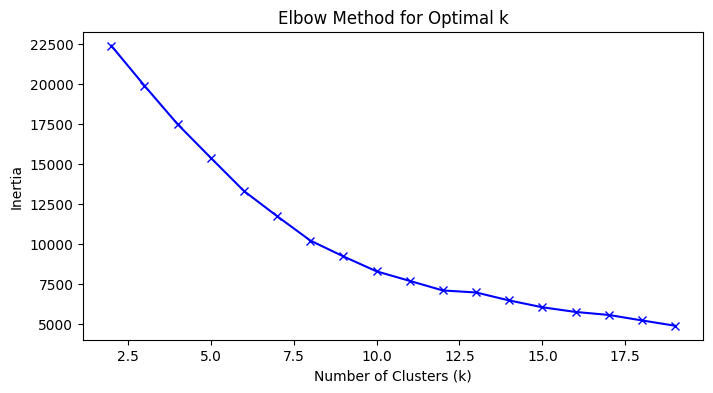

In [70]:
inertia = []
K = range(2, 20)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [72]:
# Let's assume the elbow was at 4
optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)

# Add the results back to your original dataframe
df_cleaned['Cluster'] = clusters

/var/folders/mg/9cp9yr5152g510k_59bb0gsh0000gn/T/ipykernel_91035/935450475.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



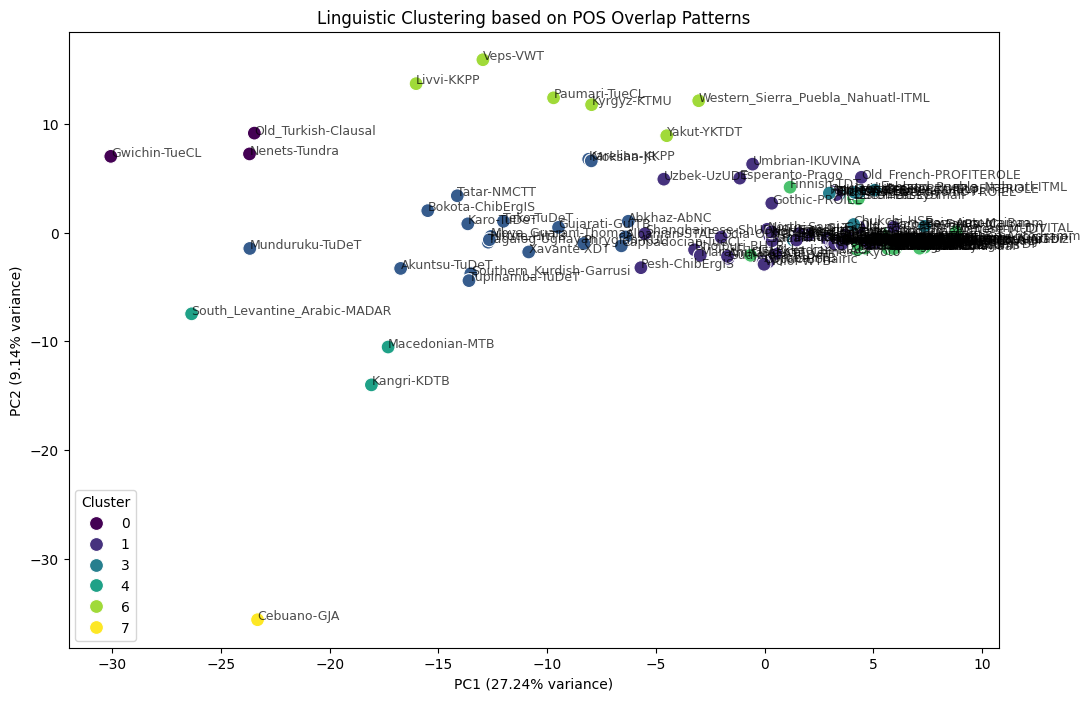

In [74]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=pca_features[:, 0], 
    y=pca_features[:, 1], 
    hue=df_cleaned['Cluster'], 
    palette='viridis',
    s=100
)

# Annotate with language names
for i, lang in enumerate(df_cleaned.index):
    plt.annotate(lang, (pca_features[i, 0], pca_features[i, 1]), 
                 fontsize=9, alpha=0.7)

plt.title("Linguistic Clustering based on POS Overlap Patterns")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.show()

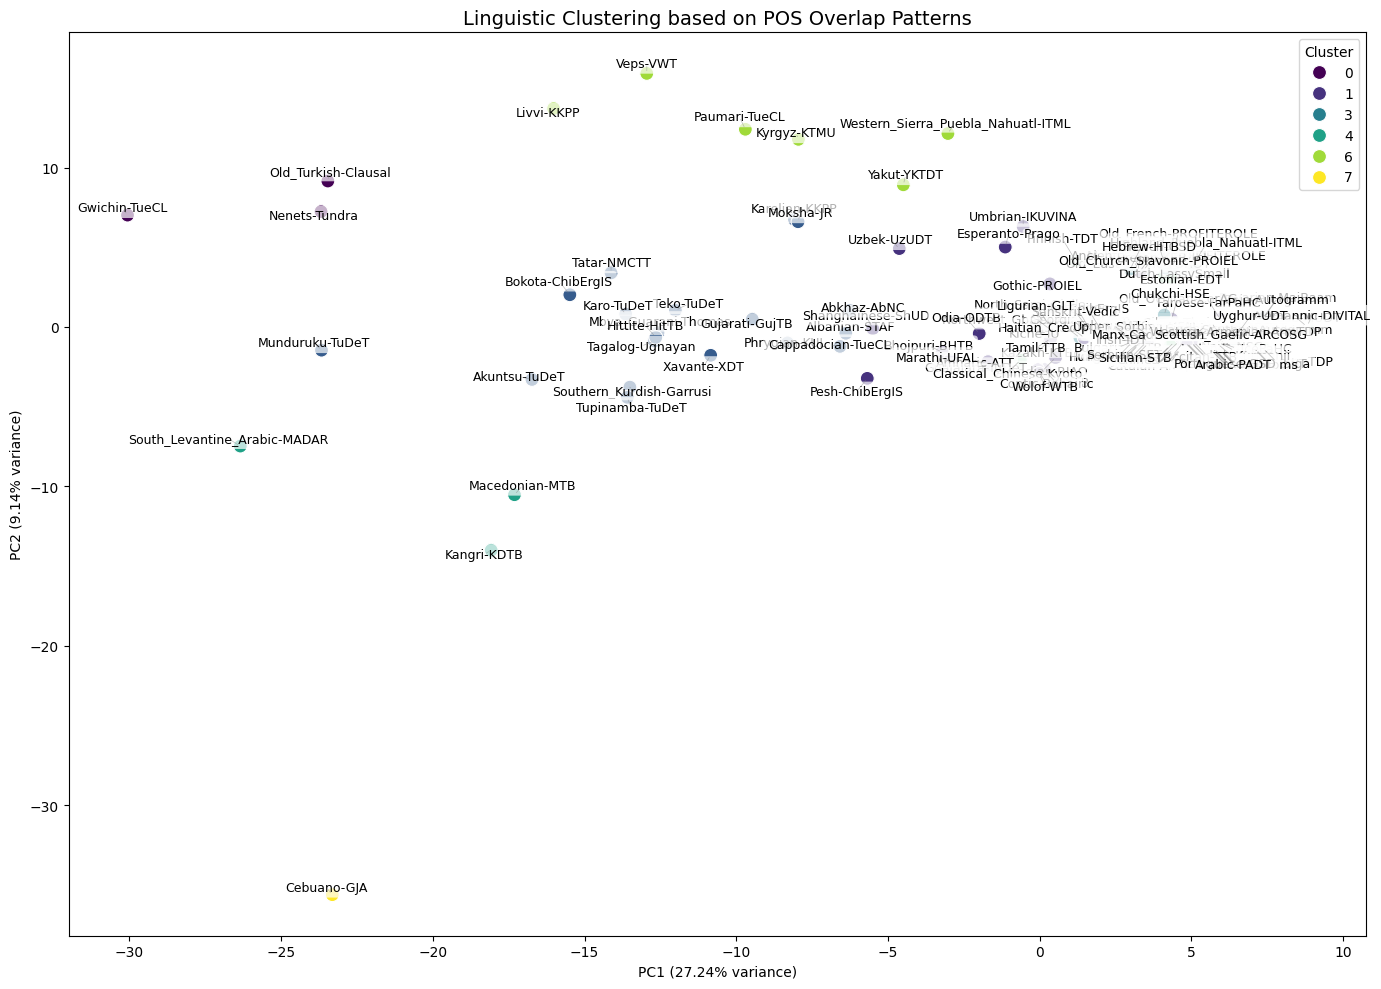

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(14, 10))

sns.scatterplot(
    x=pca_features[:, 0], 
    y=pca_features[:, 1], 
    hue=df_cleaned['Cluster'], 
    palette='viridis',
    s=100,
    ax=ax
)

# Create text annotations
texts = []
text_positions = []

for i, lang in enumerate(df_cleaned.index):
    text = ax.text(
        pca_features[i, 0], 
        pca_features[i, 1], 
        lang,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7)
    )
    texts.append(text)
    text_positions.append([pca_features[i, 0], pca_features[i, 1]])

# Adjust text positions
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5), ax=ax, expand_points=(1.5, 1.5))

ax.set_title("Linguistic Clustering based on POS Overlap Patterns", fontsize=14)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.tight_layout()
plt.show()

In [77]:
import plotly.graph_objects as go

# Create a dataframe with the PCA features
plot_df = pd.DataFrame({
    'PC1': pca_features[:, 0],
    'PC2': pca_features[:, 1],
    'Language': df_cleaned.index,
    'Cluster': df_cleaned['Cluster']
})

# Create traces for each cluster
fig = go.Figure()

for cluster in sorted(plot_df['Cluster'].unique()):
    cluster_data = plot_df[plot_df['Cluster'] == cluster]
    
    # Scatter points without text labels (for "All Clusters" view)
    fig.add_trace(
        go.Scatter(
            x=cluster_data['PC1'],
            y=cluster_data['PC2'],
            mode='markers',
            name=f'Cluster {cluster}',
            marker=dict(size=10, opacity=0.8),
            text=cluster_data['Language'],
            hovertemplate='<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<extra></extra>',
            hoverinfo='text',
            visible=True,
            showlegend=True
        )
    )
    
    # Scatter points WITH text labels (for individual cluster view)
    fig.add_trace(
        go.Scatter(
            x=cluster_data['PC1'],
            y=cluster_data['PC2'],
            mode='markers+text',
            name=f'Cluster {cluster}',
            marker=dict(size=10, opacity=0.8),
            text=cluster_data['Language'],
            textposition='top center',
            hovertemplate='<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<extra></extra>',
            hoverinfo='text',
            visible=False,
            showlegend=False
        )
    )

# Create dropdown buttons
buttons = [
    dict(
        label='All Clusters',
        method='update',
        args=[
            {'visible': [i % 2 == 0 for i in range(len(fig.data))]},
            {'title': 'Linguistic Clustering based on POS Overlap Patterns'}
        ]
    )
]

num_clusters = len(sorted(plot_df['Cluster'].unique()))
for cluster_idx, cluster in enumerate(sorted(plot_df['Cluster'].unique())):
    visible = [False] * len(fig.data)
    # Show both markers and text for this cluster
    visible[cluster_idx * 2] = False  # Hide marker-only version
    visible[cluster_idx * 2 + 1] = True  # Show marker+text version
    
    buttons.append(
        dict(
            label=f'Cluster {cluster}',
            method='update',
            args=[
                {'visible': visible},
                {'title': f'Linguistic Clustering - Cluster {cluster}'}
            ]
        )
    )

fig.update_layout(
    updatemenus=[
        dict(
            active=0,
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    title='Linguistic Clustering based on POS Overlap Patterns',
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)",
    height=800,
    width=1000,
    hovermode='closest'
)

fig.show()

In [32]:
import plotly.graph_objects as go

# Create a dataframe with the PCA features
plot_df = pd.DataFrame({
    'PC1': pca_features[:, 0],
    'PC2': pca_features[:, 1],
    'Language': adj_df.index,
    'Cluster': adj_df['Cluster']
})

fig = go.Figure()

# Add scatter points
fig.add_trace(
    go.Scatter(
        x=plot_df['PC1'],
        y=plot_df['PC2'],
        mode='markers',
        marker=dict(
            size=10,
            color=plot_df['Cluster'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Cluster")
        ),
        text=plot_df['Language'],
        hovertemplate='<b>%{text}</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<extra></extra>',
        showlegend=False
    )
)

# Add text labels with lines connecting to points
for idx, row in plot_df.iterrows():
    # Add a line from the point to the text label
    fig.add_trace(
        go.Scatter(
            x=[row['PC1'], row['PC1']],
            y=[row['PC2'], row['PC2']],
            mode='lines+text',
            line=dict(color='rgba(128, 128, 128, 0.3)', width=1),
            text=['', row['Language']],
            textposition='top center',
            hoverinfo='skip',
            showlegend=False
        )
    )

fig.update_layout(
    title='Linguistic Clustering based on POS Overlap Patterns',
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)",
    height=800,
    width=1000,
    hovermode='closest',
    font=dict(size=9)
)

fig.show()

In [48]:
df_scaled

array([[ 0.41230241,  0.30165423,  0.37850186, ...,  0.1950853 ,
        -0.79734016, -0.55904865],
       [-1.49375614,  0.57844159, -2.35605737, ...,  0.1950853 ,
        -0.79734016, -0.55904865],
       [ 0.48659927,  0.30165423,  0.34166321, ...,  0.1950853 ,
         1.06030341,  1.73318385],
       ...,
       [ 0.558734  ,  0.53466808,  0.44594536, ...,  0.40130167,
         1.18294607,  1.80813582],
       [-1.49375614,  0.79103305, -2.35605737, ...,  0.1950853 ,
        -0.79734016, -0.55904865],
       [-1.49375614,  0.31041189, -2.35605737, ...,  0.77528499,
         1.14884913,  1.73318385]])

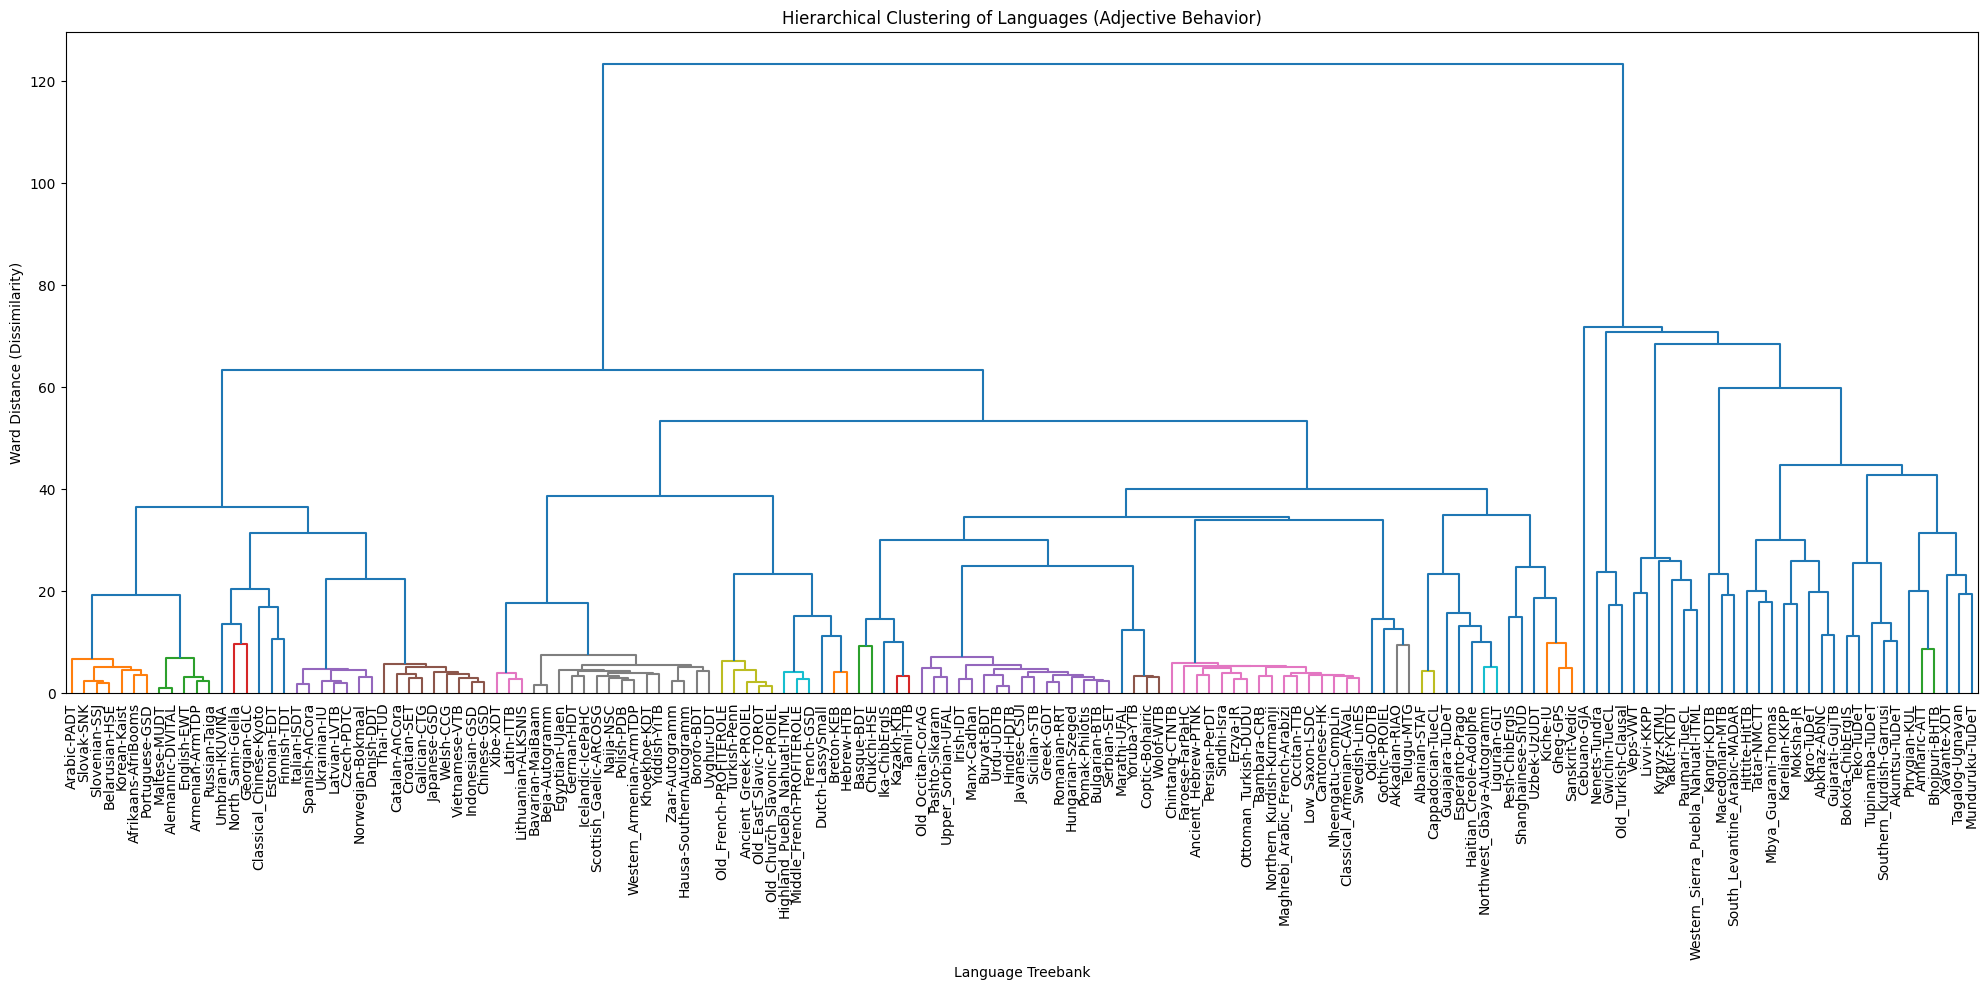

In [79]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# We use the scaled adjective data (adj_scaled) from the previous step
# 'ward' minimizes the variance of clusters being merged
linked = linkage(df_scaled, method='ward')
plt.figure(figsize=(20, 10))

# Create the dendrogram
dendro = dendrogram(
    linked,
    labels=df_cleaned.index.tolist(),  # Use language names as labels
    leaf_rotation=90,                      # Rotate names for readability
    leaf_font_size=10,
    color_threshold=10                     # This color-codes clusters at a certain distance
)

plt.title("Hierarchical Clustering of Languages (Adjective Behavior)")
plt.xlabel("Language Treebank")
plt.ylabel("Ward Distance (Dissimilarity)")
plt.tight_layout()
plt.show()